---- 30-minute slots ----
 slot     n  targets  base_rate    skill      auc  red_frac  red_precision  green_break
09:30 38570     4209   0.109126 0.561032 0.958268  0.091392       0.747518     0.000763
10:00 39900     4033   0.101078 0.649464 0.974892  0.093308       0.780285     0.000397
10:30 39900     3983   0.099825 0.647449 0.974906  0.094386       0.772438     0.000533
11:00 39900     3956   0.099148 0.647231 0.974861  0.095464       0.765293     0.000278
11:30 39900     4125   0.103383 0.643504 0.973899  0.095664       0.779146     0.000752
12:00 39899     4037   0.101180 0.645589 0.974310  0.094940       0.772439     0.000433
12:30 39897     4047   0.101436 0.626651 0.971065  0.094067       0.767120     0.000778
13:00 38400     3915   0.101953 0.627679 0.971095  0.094661       0.766162     0.000714
13:30 38400     3825   0.099609 0.619420 0.970492  0.094375       0.751104     0.000467
14:00 38400     4072   0.106042 0.605318 0.966625  0.097396       0.762834     0.000871
14:30 

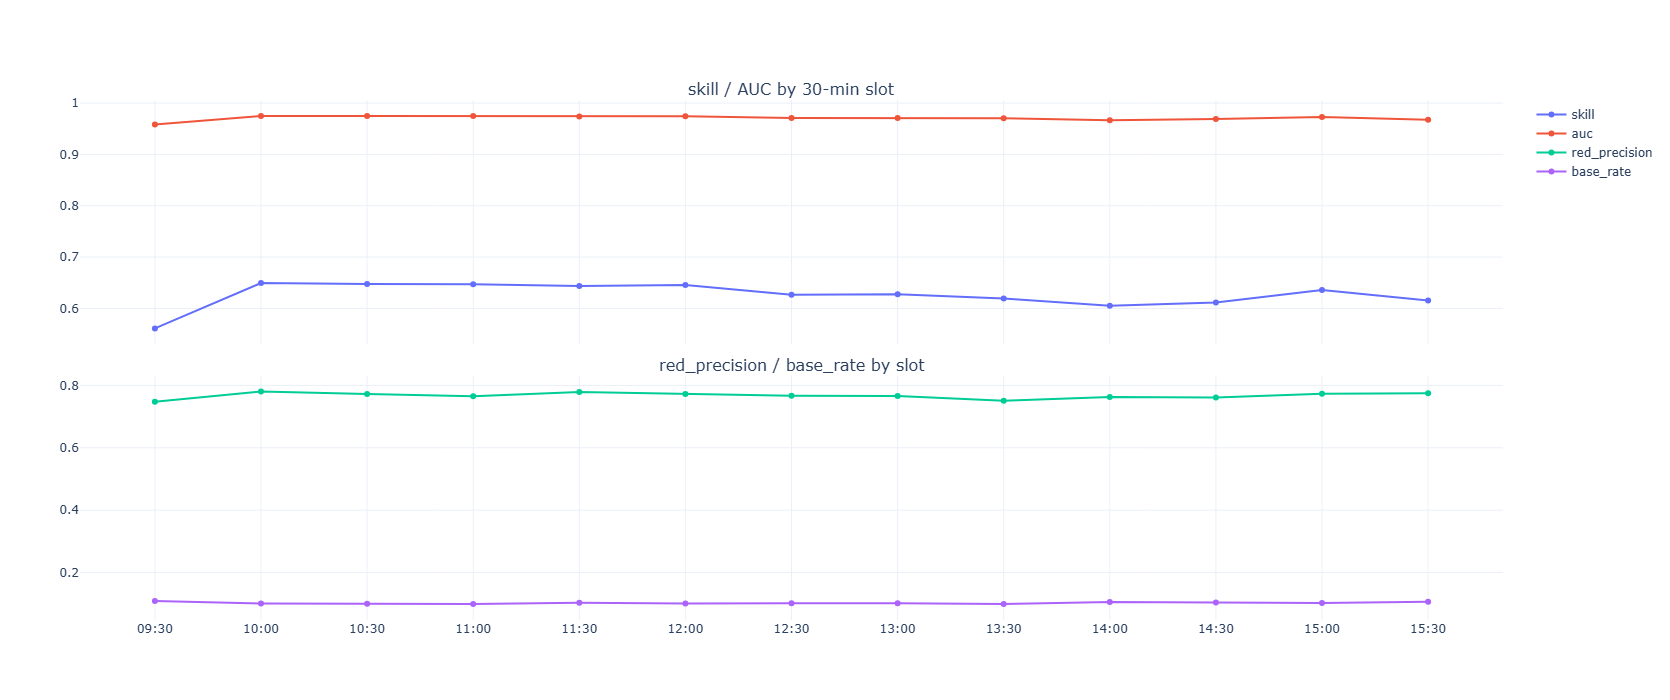

In [1]:
"""
tod_skill.py -- does model skill hold across the trading day?
Slices the deployed model's holdout predictions by time-of-day and reports
discrimination + lamp performance per slot. Pure analysis of the existing
pred parquet; no model runs.

RULES
  T.1  Per-slot null is the SLOT's own base rate: skill_slot =
       1 - LL_slot(p_cal) / LL_slot(const_slot). This measures information
       beyond "what time is it", which is the honest per-slot question.
  T.2  RED/GREEN performance per slot uses the GLOBAL frozen thresholds
       (the lamp as deployed), so red_precision per slot answers: "when the
       lamp is RED at the time I trade, how often is it right THERE."
  T.3  Two resolutions: 30-min slots across the session, and FINE_BIN-minute
       slots over [FINE_FROM, FINE_TO) for the open/macro windows.
"""

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------------- CONFIG
PRED_PATH = "data/stage-5/pred_lgbm5b_5c2raw_01-2025_6s.parquet"
GREEN_MAX = 0.0017
RED_MIN = 0.418
FINE_FROM = "09:45"          # fine-grain window (open + macro releases)
FINE_TO = "10:30"
FINE_BIN = 5                 # minutes
PLOT = True
# ----------------------------------------------------------------


def ll(y, p):
    p = np.clip(np.asarray(p, np.float64), 1e-12, 1 - 1e-12)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def slot_metrics(g):
    y = g["is_target"].to_numpy(np.float64)
    p = g["p_cal"].to_numpy(np.float64)
    r = y.mean()
    m = {"n": int(len(g)), "targets": int(y.sum()), "base_rate": float(r)}
    m["skill"] = 1.0 - ll(y, p) / ll(y, np.full_like(y, r))               # T.1
    m["auc"] = float(roc_auc_score(y, p)) if 0 < y.sum() < len(y) else np.nan
    red = p >= RED_MIN                                                     # T.2
    m["red_frac"] = float(red.mean())
    m["red_precision"] = float(y[red].mean()) if red.any() else np.nan
    green = p < GREEN_MAX
    m["green_break"] = float(y[green].mean()) if green.any() else np.nan
    return m


def by_slot(pred, minutes):
    mod = pred["timestamp"].dt.hour * 60 + pred["timestamp"].dt.minute
    slot = (mod - 570) // minutes
    rows = []
    for s, g in pred.groupby(slot):
        m = slot_metrics(g)
        lo = 570 + s * minutes
        m["slot"] = f"{lo // 60:02d}:{lo % 60:02d}"
        rows.append(m)
    cols = ["slot", "n", "targets", "base_rate", "skill", "auc",
            "red_frac", "red_precision", "green_break"]
    return pd.DataFrame(rows)[cols]


def run():
    pred = pd.read_parquet(PRED_PATH)

    coarse = by_slot(pred, 30)
    print("---- 30-minute slots ----")
    print(coarse.to_string(index=False))

    lo = pd.Timestamp(FINE_FROM).time()
    hi = pd.Timestamp(FINE_TO).time()
    fine = by_slot(pred[(pred["timestamp"].dt.time >= lo)
                        & (pred["timestamp"].dt.time < hi)], FINE_BIN)
    print(f"---- {FINE_BIN}-minute slots, {FINE_FROM}-{FINE_TO} ----")
    print(fine.to_string(index=False))

    g = pred.assign(mod=pred["timestamp"].dt.hour * 60
                    + pred["timestamp"].dt.minute)
    worst = coarse.sort_values("skill").head(3)
    print("---- weakest 30-min slots ----")
    print(worst.to_string(index=False))

    if PLOT:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                            vertical_spacing=0.06,
                            subplot_titles=["skill / AUC by 30-min slot",
                                            "red_precision / base_rate by slot"])
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["skill"],
                                 mode="lines+markers", name="skill"), row=1, col=1)
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["auc"],
                                 mode="lines+markers", name="auc"), row=1, col=1)
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["red_precision"],
                                 mode="lines+markers", name="red_precision"),
                      row=2, col=1)
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["base_rate"],
                                 mode="lines+markers", name="base_rate"),
                      row=2, col=1)
        fig.update_layout(height=700, width=1300, template="plotly_white",
                          hovermode="x unified")
        fig.show()

    return coarse, fine


# ---------------------------------------------------------------- usage
coarse, fine = run()

In [2]:
print(coarse)
print(fine)

     slot      n  targets  base_rate     skill       auc  red_frac  \
0   09:30  38570     4209   0.109126  0.561032  0.958268  0.091392   
1   10:00  39900     4033   0.101078  0.649464  0.974892  0.093308   
2   10:30  39900     3983   0.099825  0.647449  0.974906  0.094386   
3   11:00  39900     3956   0.099148  0.647231  0.974861  0.095464   
4   11:30  39900     4125   0.103383  0.643504  0.973899  0.095664   
5   12:00  39899     4037   0.101180  0.645589  0.974310  0.094940   
6   12:30  39897     4047   0.101436  0.626651  0.971065  0.094067   
7   13:00  38400     3915   0.101953  0.627679  0.971095  0.094661   
8   13:30  38400     3825   0.099609  0.619420  0.970492  0.094375   
9   14:00  38400     4072   0.106042  0.605318  0.966625  0.097396   
10  14:30  38400     3994   0.104010  0.611593  0.968866  0.094505   
11  15:00  38400     3928   0.102292  0.635722  0.972980  0.094167   
12  15:30  38400     4074   0.106094  0.615682  0.967532  0.098516   

    red_precision  